# 네트워크 침입 탐지 — MLflow Pipeline v6

## 가설 H6: Benign/Attack과 공격 유형을 분리하면 DoS와 Infilteration 오류를 줄일 수 있다

v5 Champion 혼동행렬의 핵심 오류는 다음 두 가지입니다.

- Benign 4,091건 → Infilteration 오탐
- DoS 5,586건 중 3,586건 → Brute Force 오분류

v6는 v5의 `past_context_only` 피처와 동일한 클래스별 시간 블록 검증을 유지하고 계층형 모델을 비교합니다.

1. Stage 1: `Benign` vs `Attack`
2. Stage 2: `Brute Force` / `DDOS` / `DoS` / `Infilteration`
3. Stage 1 임계값과 Stage 2 DoS 가중치를 탐색

안전조건은 v5 flat baseline 대비 Accuracy 하락 0.02 이내, Infilteration Recall 0.40 이상,
Benign→Infilteration 오탐이 baseline 이하인 것입니다.
조건을 만족하는 후보 중 공격 Macro F1이 가장 높은 모델을 선택합니다.


In [1]:
from pathlib import Path
import json
import os
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

HYPOTHESIS_ID = "v6"
HYPOTHESIS = "hierarchical_benign_attack_and_attack_subtype"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

WORK_ROOT = Path("/home/jovyan/work")
cwd = Path.cwd()
PROJECT_NAME = cwd.parent.name if cwd.name == "notebooks" else "network-classification"
PROJECT_DIR = WORK_ROOT / PROJECT_NAME
DATA_BASE = WORK_ROOT / "datasets"

def has_temporal_train(project_dir: Path) -> bool:
    return (project_dir / "processed" / "train_temporal_v5.parquet").exists()

preferred = DATA_BASE / PROJECT_NAME
if has_temporal_train(preferred):
    DATA_ROOT = preferred
else:
    matches = [p for p in DATA_BASE.iterdir() if p.is_dir() and has_temporal_train(p)]
    if len(matches) != 1:
        raise RuntimeError(f"v5 temporal 데이터 프로젝트를 결정할 수 없습니다: {matches}")
    DATA_ROOT = matches[0]

PROCESSED_DIR = DATA_ROOT / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_TEMPORAL = PROCESSED_DIR / "train_temporal_v5.parquet"
TEST_TEMPORAL = PROCESSED_DIR / "test_temporal_v5.parquet"

ID_COL = "unique_id"
TARGET = "Label"
CAT_FEATURES = ["Dst Port", "Protocol"]
CALENDAR_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "elapsed_hours"]
TRAIN_SAMPLE = 250_000
VALID_FRACTION = 0.20
MIN_INFILTRATION_RECALL = 0.40
MAX_ACCURACY_DROP = 0.02
DOS_MULTIPLIERS = [1.0, 2.0, 4.0]
THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.05), 2)

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
EXPERIMENT_NAME = f"{PROJECT_NAME}-ids-{HYPOTHESIS_ID}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Project    :", PROJECT_NAME)
print("Data root  :", DATA_ROOT)
print("Output     :", OUTPUT_DIR)
print("Experiment :", EXPERIMENT_NAME)


Project    : network-classification
Data root  : /home/jovyan/work/datasets/ 📁 network-classification
Output     : /home/jovyan/work/network-classification/outputs/v6
Experiment : network-classification-ids-v6


## 1. v5 시간 피처 샘플 및 IDS 피처 로딩

In [2]:
def sql_path(path: Path) -> str:
    return str(path).replace("'", "''")

def parquet_expr(path: Path) -> str:
    return f"read_parquet('{sql_path(path)}')"

def load_sample(path: Path, n_rows: int):
    with duckdb.connect() as con:
        return con.execute(f'''
            SELECT * FROM {parquet_expr(path)}
            USING SAMPLE reservoir({int(n_rows)} ROWS)
            REPEATABLE ({RANDOM_STATE})
        ''').df()

def add_ids_features(df: pd.DataFrame):
    df = df.copy()
    flag_cols = [
        "SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt",
        "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt",
    ]
    if all(c in df.columns for c in flag_cols):
        values = {
            c: pd.to_numeric(df[c], errors="coerce").fillna(0).astype(float)
            for c in flag_cols
        }
        syn, ack = values["SYN Flag Cnt"], values["ACK Flag Cnt"]
        rst, fin = values["RST Flag Cnt"], values["FIN Flag Cnt"]
        urg, psh = values["URG Flag Cnt"], values["PSH Flag Cnt"]
        total_flags = syn + ack + rst + fin + urg + psh + 1.0
        df["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
        df["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
        df["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
        df["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
        df["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
        df["SYN_share"] = (syn + 1) / total_flags
        df["RST_share"] = (rst + 1) / total_flags
    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
    return df

train_df = add_ids_features(load_sample(TRAIN_TEMPORAL, TRAIN_SAMPLE))
train_df["Timestamp"] = pd.to_datetime(train_df["Timestamp"])
classes = sorted(train_df[TARGET].astype(str).unique().tolist())
attack_classes = [c for c in classes if c != "Benign"]
INFILTRATION_LABEL = next(
    c for c in classes if c.lower() in {"infiltration", "infilteration"}
)

X_all = train_df.drop(
    columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore"
)
y_all = train_df[TARGET].astype(str)
for column in CAT_FEATURES:
    if column in X_all.columns:
        X_all[column] = X_all[column].astype("string")

print("Loaded:", train_df.shape, "Model features:", X_all.shape[1])
print("Classes:", classes)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded: (250000, 62) Model features: 54
Classes: ['Benign', 'Brute Force', 'DDOS', 'DoS', 'Infilteration']


## 2. v5와 동일한 클래스별 시간 블록 분할

In [3]:
class_cutoffs = train_df.groupby(TARGET)["Timestamp"].quantile(1 - VALID_FRACTION)
cutoff_per_row = train_df[TARGET].map(class_cutoffs)
valid_mask = train_df["Timestamp"] > cutoff_per_row
train_mask = ~valid_mask

X_train, X_valid = X_all.loc[train_mask], X_all.loc[valid_mask]
y_train, y_valid = y_all.loc[train_mask], y_all.loc[valid_mask]

split_distribution = pd.crosstab(
    pd.Series(np.where(valid_mask, "valid_late", "train_early"), index=train_df.index),
    y_all,
)
display(class_cutoffs.to_frame("cutoff"))
display(split_distribution)
assert (split_distribution > 0).all().all()
print("Train:", X_train.shape, "Valid:", X_valid.shape)


,cutoff
Label,
Benign,2018-02-28 11:15:54.000
Brute Force,2018-02-14 11:32:57.200
DDOS,2018-02-21 02:27:14.000
DoS,2018-02-16 10:13:27.000
Infilteration,2018-03-01 03:34:09.000


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
train_early,137495,13146,23894,22345,3132
valid_late,34373,3287,5965,5586,777


Train: (200012, 54) Valid: (49988, 54)


In [4]:
def make_preprocessor(frame):
    cat_features = [c for c in CAT_FEATURES if c in frame.columns]
    num_features = [c for c in frame.columns if c not in cat_features]
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler()),
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), cat_features),
    ])

def make_lgbm(objective, class_weight, n_estimators=500):
    return LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective=objective,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

def evaluate(y_true, y_pred):
    metrics = {
        "weighted_f1_attacks": float(f1_score(
            y_true, y_pred, labels=attack_classes,
            average="weighted", zero_division=0,
        )),
        "macro_f1_attacks": float(f1_score(
            y_true, y_pred, labels=attack_classes,
            average="macro", zero_division=0,
        )),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for label, prefix in [(INFILTRATION_LABEL, "infilteration"), ("DoS", "dos")]:
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[label], average=None, zero_division=0
        )
        metrics[f"{prefix}_precision"] = float(p[0])
        metrics[f"{prefix}_recall"] = float(r[0])
        metrics[f"{prefix}_f1"] = float(f[0])
    yt, yp = np.asarray(y_true), np.asarray(y_pred)
    metrics["benign_to_infilteration_fp"] = int(np.sum(
        (yt == "Benign") & (yp == INFILTRATION_LABEL)
    ))
    metrics["dos_to_bruteforce"] = int(np.sum(
        (yt == "DoS") & (yp == "Brute Force")
    ))
    return metrics

def save_evaluation(name, y_true, y_pred):
    report_path = OUTPUT_DIR / f"{name}_classification_report.csv"
    pd.DataFrame(classification_report(
        y_true, y_pred, labels=classes, output_dict=True, zero_division=0
    )).T.to_csv(report_path, encoding="utf-8-sig")
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set(title=f"Confusion Matrix — {name}", xlabel="Predicted", ylabel="Actual")
    plt.tight_layout()
    cm_path = OUTPUT_DIR / f"{name}_confusion_matrix.png"
    fig.savefig(cm_path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    return report_path, cm_path


## 3. Flat baseline 재현

In [5]:
flat_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.asarray(classes), y=y_train.to_numpy()
)
flat_weights = dict(zip(classes, flat_weight_values.astype(float)))
flat_weights[INFILTRATION_LABEL] *= 0.50

flat_pipeline = Pipeline([
    ("preprocess", make_preprocessor(X_all)),
    ("model", make_lgbm("multiclass", flat_weights)),
])

with mlflow.start_run(run_name="v6_flat_baseline") as flat_run:
    mlflow.set_tags({
        "project": PROJECT_NAME,
        "hypothesis_id": HYPOTHESIS_ID,
        "model_structure": "flat",
        "validation": "within_class_chronological_80_20",
    })
    started = time.time()
    flat_pipeline.fit(X_train, y_train)
    flat_pred = flat_pipeline.predict(X_valid)
    flat_metrics = evaluate(y_valid, flat_pred)
    flat_metrics["train_seconds"] = time.time() - started
    mlflow.log_metrics(flat_metrics)
    mlflow.log_params({"inf_weight_multiplier": 0.5, "n_features": X_all.shape[1]})
    flat_report, flat_cm = save_evaluation("v6_flat_baseline", y_valid, flat_pred)
    mlflow.log_artifact(str(flat_report), artifact_path="evaluation")
    mlflow.log_artifact(str(flat_cm), artifact_path="evaluation")
    mlflow.sklearn.log_model(
        flat_pipeline, name="model",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    flat_run_id = flat_run.info.run_id

print("Flat baseline:", flat_metrics, "run_id=", flat_run_id)


2026/08/15 15:55:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v6_flat_baseline at: http://mlflow:5000/#/experiments/5/runs/e464380d1250447f8b63da0f6092a9a0
🧪 View experiment at: http://mlflow:5000/#/experiments/5
Flat baseline: {'weighted_f1_attacks': 0.7115374338053269, 'macro_f1_attacks': 0.5781985194330038, 'accuracy': 0.8369208610066416, 'infilteration_precision': 0.08560572194903888, 'infilteration_recall': 0.4929214929214929, 'infilteration_f1': 0.14587697581413064, 'dos_precision': 1.0, 'dos_recall': 0.35803795202291444, 'dos_f1': 0.5272871078302136, 'benign_to_infilteration_fp': 4091, 'dos_to_bruteforce': 3586, 'train_seconds': 25.921937942504883} run_id= e464380d1250447f8b63da0f6092a9a0


## 4. Stage 1 — Benign vs Attack

In [6]:
y_train_binary = (y_train != "Benign").astype(int)
y_valid_binary = (y_valid != "Benign").astype(int)

stage1_pipeline = Pipeline([
    ("preprocess", make_preprocessor(X_all)),
    ("model", make_lgbm("binary", "balanced", n_estimators=400)),
])
stage1_started = time.time()
stage1_pipeline.fit(X_train, y_train_binary)
stage1_valid_probability = stage1_pipeline.predict_proba(X_valid)[:, 1]

print("Stage 1 train seconds:", time.time() - stage1_started)
print(pd.Series(stage1_valid_probability).describe(percentiles=[.1, .25, .5, .75, .9]))


Stage 1 train seconds: 5.289815187454224
count    49988.000000
mean         0.371327
std          0.451667
min          0.000006
10%          0.000107
25%          0.000369
50%          0.015031
75%          0.999928
90%          0.999996
max          0.999997
dtype: float64


## 5. Stage 2 — 공격 유형 분류와 DoS 가중치 탐색

In [7]:
attack_train_mask = y_train != "Benign"
X_attack_train = X_train.loc[attack_train_mask]
y_attack_train = y_train.loc[attack_train_mask]

attack_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.asarray(attack_classes),
    y=y_attack_train.to_numpy(),
)
base_attack_weights = dict(zip(attack_classes, attack_weight_values.astype(float)))
display(pd.Series(base_attack_weights, name="base_attack_weight").to_frame())

hierarchical_models = {}
candidate_rows = []

for dos_multiplier in DOS_MULTIPLIERS:
    attack_weights = base_attack_weights.copy()
    attack_weights["DoS"] *= dos_multiplier
    stage2_pipeline = Pipeline([
        ("preprocess", make_preprocessor(X_all)),
        ("model", make_lgbm("multiclass", attack_weights)),
    ])
    started = time.time()
    stage2_pipeline.fit(X_attack_train, y_attack_train)
    stage2_valid_pred = stage2_pipeline.predict(X_valid)
    train_seconds = time.time() - started
    hierarchical_models[dos_multiplier] = stage2_pipeline

    for threshold in THRESHOLDS:
        combined_pred = np.where(
            stage1_valid_probability >= threshold,
            stage2_valid_pred,
            "Benign",
        )
        metrics = evaluate(y_valid, combined_pred)
        candidate_rows.append({
            "dos_multiplier": dos_multiplier,
            "attack_threshold": threshold,
            **metrics,
            "stage2_train_seconds": train_seconds,
        })

candidates = pd.DataFrame(candidate_rows)
candidates_path = OUTPUT_DIR / "v6_hierarchical_threshold_search.csv"
candidates.to_csv(candidates_path, index=False, encoding="utf-8-sig")
display(candidates.sort_values("macro_f1_attacks", ascending=False).head(20))


,base_attack_weight
Brute Force,1.188898
DDOS,0.654108
DoS,0.699452
Infilteration,4.990182


,dos_multiplier,attack_threshold,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp,dos_to_bruteforce,stage2_train_seconds
3,1.0,0.25,0.920468,0.755926,0.881031,0.092202,0.658945,0.161769,0.998809,0.900823,0.947289,5041,554,5.138603
4,1.0,0.30,0.920540,0.755736,0.888593,0.092567,0.607465,0.160654,0.999603,0.900823,0.947646,4627,554,5.138603
2,1.0,0.20,0.920322,0.755329,0.872669,0.090005,0.698842,0.159471,0.998611,0.900823,0.947200,5490,554,5.138603
20,2.0,0.25,0.919372,0.755174,0.880671,0.092169,0.658945,0.161718,0.995647,0.900823,0.945865,5043,554,5.262196
21,2.0,0.30,0.919443,0.754984,0.888233,0.092531,0.607465,0.160599,0.996436,0.900823,0.946220,4629,554,5.262196
5,1.0,0.35,0.920405,0.754921,0.895755,0.091788,0.549550,0.157303,0.999801,0.900823,0.947735,4225,554,5.138603
1,1.0,0.15,0.920222,0.754826,0.863007,0.088012,0.746461,0.157459,0.998611,0.900823,0.947200,6010,554,5.138603
0,1.0,0.10,0.920140,0.754693,0.851044,0.086921,0.815959,0.157106,0.998215,0.900823,0.947022,6660,554,5.138603
19,2.0,0.20,0.919226,0.754579,0.872309,0.089975,0.698842,0.159425,0.995450,0.900823,0.945776,5492,554,5.262196
22,2.0,0.35,0.919278,0.754152,0.895395,0.091769,0.549550,0.157274,0.996436,0.900823,0.946220,4226,554,5.262196


## 6. 안전조건 적용 및 계층형 Champion 선택

In [8]:
eligible = candidates[
    (candidates["accuracy"] >= flat_metrics["accuracy"] - MAX_ACCURACY_DROP)
    & (candidates["infilteration_recall"] >= MIN_INFILTRATION_RECALL)
    & (candidates["benign_to_infilteration_fp"]
       <= flat_metrics["benign_to_infilteration_fp"])
]

if eligible.empty:
    print("안전조건을 만족하는 계층형 후보가 없습니다. Flat baseline을 유지합니다.")
    champion_structure = "flat"
    champion_metrics = flat_metrics
    champion_pred = flat_pred
    selected_threshold = None
    selected_dos_multiplier = None
else:
    selected = eligible.sort_values(
        ["macro_f1_attacks", "weighted_f1_attacks", "accuracy"],
        ascending=False,
    ).iloc[0]
    selected_threshold = float(selected["attack_threshold"])
    selected_dos_multiplier = float(selected["dos_multiplier"])
    champion_pred = np.where(
        stage1_valid_probability >= selected_threshold,
        hierarchical_models[selected_dos_multiplier].predict(X_valid),
        "Benign",
    )
    champion_metrics = evaluate(y_valid, champion_pred)
    champion_structure = "hierarchical"

improvements = {
    key: champion_metrics[key] - flat_metrics[key]
    for key in [
        "weighted_f1_attacks", "macro_f1_attacks", "accuracy",
        "infilteration_precision", "infilteration_recall", "infilteration_f1",
        "dos_precision", "dos_recall", "dos_f1",
        "benign_to_infilteration_fp", "dos_to_bruteforce",
    ]
}

print("Champion structure     :", champion_structure)
print("Selected threshold     :", selected_threshold)
print("Selected DoS multiplier:", selected_dos_multiplier)
print("Champion metrics       :", champion_metrics)
print("Delta vs flat          :", improvements)


Champion structure     : hierarchical
Selected threshold     : 0.45
Selected DoS multiplier: 1.0
Champion metrics       : {'weighted_f1_attacks': 0.9202514012197288, 'macro_f1_attacks': 0.7541476007767233, 'accuracy': 0.9089381451548372, 'infilteration_precision': 0.09265507396833636, 'infilteration_recall': 0.4594594594594595, 'infilteration_f1': 0.15421166306695464, 'dos_precision': 0.9998013113451222, 'dos_recall': 0.9008234872896527, 'dos_f1': 0.9477351916376306, 'benign_to_infilteration_fp': 3496, 'dos_to_bruteforce': 554}
Delta vs flat          : {'weighted_f1_attacks': 0.20871396741440196, 'macro_f1_attacks': 0.17594908134371945, 'accuracy': 0.07201728414819553, 'infilteration_precision': 0.007049352019297475, 'infilteration_recall': -0.033462033462033414, 'infilteration_f1': 0.008334687252823991, 'dos_precision': -0.00019868865487782106, 'dos_recall': 0.5427855352667382, 'dos_f1': 0.42044808380741705, 'benign_to_infilteration_fp': -595, 'dos_to_bruteforce': -3032}


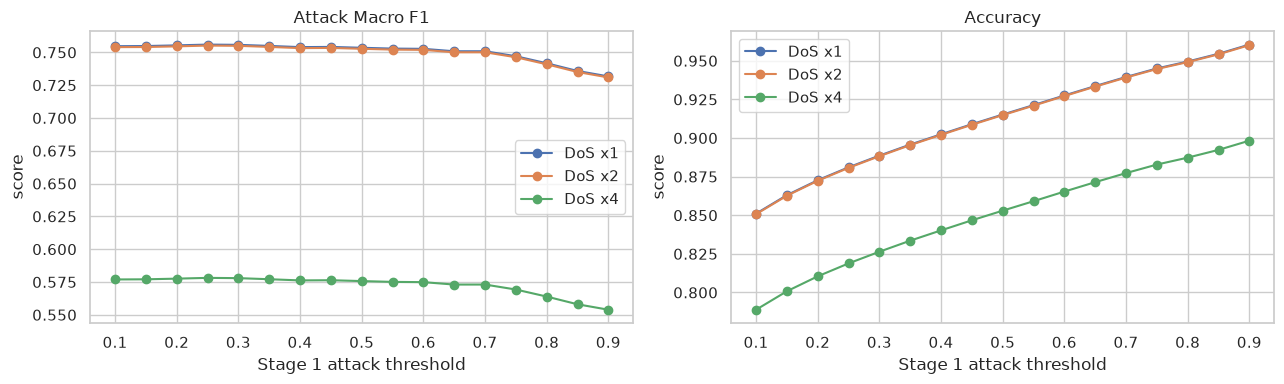

In [9]:
champion_report, champion_cm = save_evaluation(
    "v6_hierarchical_champion" if champion_structure == "hierarchical" else "v6_flat_champion",
    y_valid,
    champion_pred,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for multiplier, group in candidates.groupby("dos_multiplier"):
    axes[0].plot(group["attack_threshold"], group["macro_f1_attacks"], marker="o", label=f"DoS x{multiplier:g}")
    axes[1].plot(group["attack_threshold"], group["accuracy"], marker="o", label=f"DoS x{multiplier:g}")
axes[0].set(title="Attack Macro F1", xlabel="Stage 1 attack threshold", ylabel="score")
axes[1].set(title="Accuracy", xlabel="Stage 1 attack threshold", ylabel="score")
for ax in axes:
    ax.legend()
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "v6_threshold_tradeoff.png"
fig.savefig(tradeoff_path, dpi=140, bbox_inches="tight")
plt.show()


## 7. MLflow Champion 기록 및 전체 샘플 재학습

In [10]:
if champion_structure == "hierarchical":
    selected_stage2 = hierarchical_models[selected_dos_multiplier]
    with mlflow.start_run(run_name="v6_hierarchical_champion_validation") as validation_run:
        mlflow.set_tags({
            "project": PROJECT_NAME,
            "hypothesis_id": HYPOTHESIS_ID,
            "hypothesis": HYPOTHESIS,
            "model_structure": "hierarchical",
            "validation": "within_class_chronological_80_20",
        })
        mlflow.log_params({
            "attack_threshold": selected_threshold,
            "dos_weight_multiplier": selected_dos_multiplier,
            "threshold_candidates": len(THRESHOLDS),
        })
        mlflow.log_metrics(champion_metrics)
        mlflow.log_artifact(str(candidates_path), artifact_path="search")
        mlflow.log_artifact(str(champion_report), artifact_path="evaluation")
        mlflow.log_artifact(str(champion_cm), artifact_path="evaluation")
        mlflow.log_artifact(str(tradeoff_path), artifact_path="evaluation")
        mlflow.sklearn.log_model(
            stage1_pipeline, name="stage1_benign_attack",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )
        mlflow.sklearn.log_model(
            selected_stage2, name="stage2_attack_subtype",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )
        validation_run_id = validation_run.info.run_id

    final_stage1 = clone(stage1_pipeline)
    final_stage2 = clone(selected_stage2)
    y_all_binary = (y_all != "Benign").astype(int)
    attack_all_mask = y_all != "Benign"

    with mlflow.start_run(run_name="v6_hierarchical_full_refit") as final_run:
        mlflow.set_tags({
            "project": PROJECT_NAME,
            "hypothesis_id": HYPOTHESIS_ID,
            "stage": "full_sample_refit",
            "model_structure": "hierarchical",
        })
        mlflow.log_params({
            "attack_threshold": selected_threshold,
            "dos_weight_multiplier": selected_dos_multiplier,
            "train_rows": len(X_all),
            "attack_train_rows": int(attack_all_mask.sum()),
            "source_validation_run_id": validation_run_id,
        })
        started = time.time()
        final_stage1.fit(X_all, y_all_binary)
        final_stage2.fit(X_all.loc[attack_all_mask], y_all.loc[attack_all_mask])
        mlflow.log_metric("train_seconds", time.time() - started)
        mlflow.sklearn.log_model(
            final_stage1, name="stage1_benign_attack",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )
        mlflow.sklearn.log_model(
            final_stage2, name="stage2_attack_subtype",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )
        final_run_id = final_run.info.run_id
else:
    validation_run_id = flat_run_id
    final_flat = clone(flat_pipeline)
    with mlflow.start_run(run_name="v6_flat_full_refit") as final_run:
        final_flat.fit(X_all, y_all)
        mlflow.sklearn.log_model(
            final_flat, name="model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )
        final_run_id = final_run.info.run_id

print("Validation run:", validation_run_id)
print("Final run     :", final_run_id)


2026/08/15 15:56:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/15 15:56:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v6_hierarchical_champion_validation at: http://mlflow:5000/#/experiments/5/runs/4dc06735cbfe40f981c74df531adcf8a
🧪 View experiment at: http://mlflow:5000/#/experiments/5


2026/08/15 15:56:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/15 15:56:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v6_hierarchical_full_refit at: http://mlflow:5000/#/experiments/5/runs/24bfd469769147f0b3d252f7589bc208
🧪 View experiment at: http://mlflow:5000/#/experiments/5
Validation run: 4dc06735cbfe40f981c74df531adcf8a
Final run     : 24bfd469769147f0b3d252f7589bc208


## 8. Test 예측 및 제출 검증

In [11]:
def load_full(path: Path):
    with duckdb.connect() as con:
        return con.execute(f"SELECT * FROM {parquet_expr(path)}").df()

test_df = add_ids_features(load_full(TEST_TEMPORAL))
test_ids = test_df[ID_COL].copy()
X_test = test_df.drop(
    columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore"
)
for column in CAT_FEATURES:
    if column in X_test.columns:
        X_test[column] = X_test[column].astype("string")
X_test = X_test[X_all.columns]

if champion_structure == "hierarchical":
    test_attack_probability = final_stage1.predict_proba(X_test)[:, 1]
    test_attack_subtype = final_stage2.predict(X_test)
    test_pred = np.where(
        test_attack_probability >= selected_threshold,
        test_attack_subtype,
        "Benign",
    )
else:
    test_pred = final_flat.predict(X_test)

submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_pred}).set_index(ID_COL)
submission_path = OUTPUT_DIR / "submission_v6.csv"
submission.to_csv(submission_path, encoding="utf-8-sig")

checks = {
    "rows": len(submission),
    "expected_rows": len(test_df),
    "label_missing": int(submission[TARGET].isna().sum()),
    "duplicate_id": int(submission.index.duplicated().sum()),
    "unknown_labels": sorted(set(submission[TARGET]) - set(classes)),
}
print("Saved:", submission_path)
print("Checks:", checks)
display(submission[TARGET].value_counts().to_frame("count"))
assert checks["rows"] == checks["expected_rows"]
assert checks["label_missing"] == 0
assert checks["duplicate_id"] == 0
assert not checks["unknown_labels"]


Saved: /home/jovyan/work/network-classification/outputs/v6/submission_v6.csv
Checks: {'rows': 1159701, 'expected_rows': 1159701, 'label_missing': 0, 'duplicate_id': 0, 'unknown_labels': []}


,count
Label,
Benign,807849
DoS,140415
DDOS,125638
Brute Force,76082
Infilteration,9717


## 9. 가설 판정

In [12]:
hypothesis_supported = (
    champion_structure == "hierarchical"
    and champion_metrics["macro_f1_attacks"] > flat_metrics["macro_f1_attacks"]
)
print("Hypothesis supported:", hypothesis_supported)
print("Champion structure  :", champion_structure)
print("Validation run      :", validation_run_id)
print("Final run           :", final_run_id)
print("Search CSV          :", candidates_path)
print("Submission          :", submission_path)


Hypothesis supported: True
Champion structure  : hierarchical
Validation run      : 4dc06735cbfe40f981c74df531adcf8a
Final run           : 24bfd469769147f0b3d252f7589bc208
Search CSV          : /home/jovyan/work/network-classification/outputs/v6/v6_hierarchical_threshold_search.csv
Submission          : /home/jovyan/work/network-classification/outputs/v6/submission_v6.csv
